In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/netflix_titles.csv')

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [2]:
# Check dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [3]:
# Check missing values
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [4]:
# Create a copy for analysis
df_clean = df.copy()

# Fill missing values
df_clean['director'] = df_clean['director'].fillna('Unknown')
df_clean['cast'] = df_clean['cast'].fillna('Unknown')
df_clean['country'] = df_clean['country'].fillna('Unknown')
df_clean['date_added'] = df_clean['date_added'].fillna('Unknown')
df_clean['rating'] = df_clean['rating'].fillna('Unknown')
df_clean['duration'] = df_clean['duration'].fillna('Unknown')

# Check remaining missing values
df_clean.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


In [5]:
# Count Movies vs TV Shows
type_counts = df_clean['type'].value_counts()

print(type_counts)

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


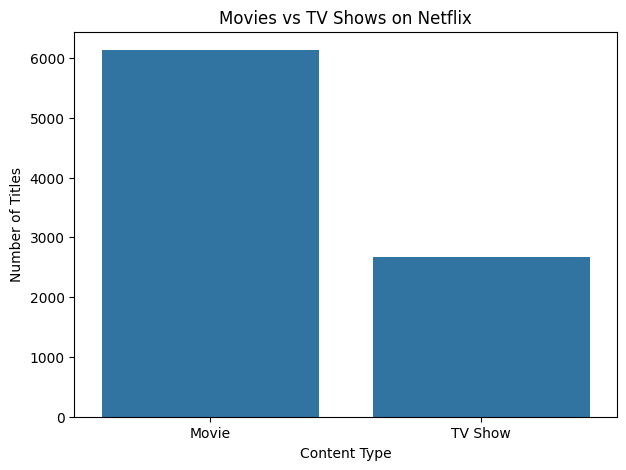

In [6]:
# Visualization 1: Movies vs TV Shows

plt.figure(figsize=(7, 5))

sns.countplot(data=df_clean, x='type')

plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')

plt.show()

In [7]:
# Convert date_added to datetime
df_clean['date_added'] = pd.to_datetime(
    df_clean['date_added'],
    errors='coerce'
)

# Extract year
df_clean['year_added'] = df_clean['date_added'].dt.year

# Count titles added each year
yearly_content = df_clean['year_added'].value_counts().sort_index()

print(yearly_content)

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: count, dtype: int64


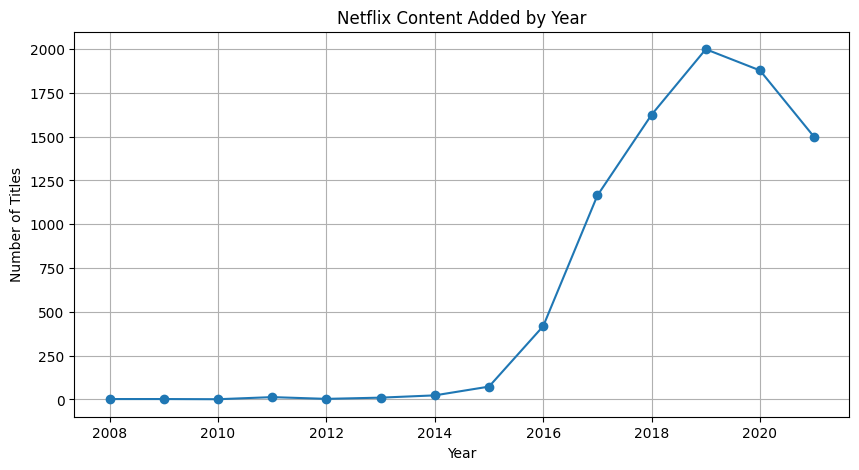

In [8]:
# Visualization 2: Content Added by Year

plt.figure(figsize=(10, 5))

plt.plot(yearly_content.index, yearly_content.values, marker='o')

plt.title('Netflix Content Added by Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles')

plt.grid(True)
plt.show()

In [9]:
# Split genres and count them
genre_counts = (
    df_clean['listed_in']
    .str.split(', ')
    .explode()
    .value_counts()
)

print(genre_counts.head(10))

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


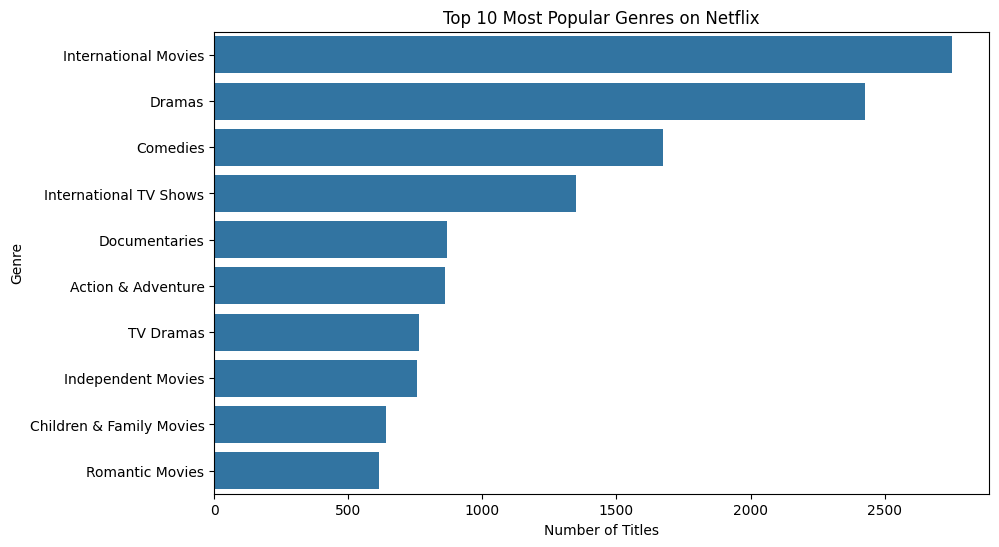

In [10]:
# Visualization 3: Top 10 Genres

top_genres = genre_counts.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title('Top 10 Most Popular Genres on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')

plt.show()

In [11]:
# Count titles by rating
rating_counts = df_clean['rating'].value_counts()

print(rating_counts)

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
Unknown        4
NC-17          3
UR             3
66 min         1
74 min         1
84 min         1
Name: count, dtype: int64


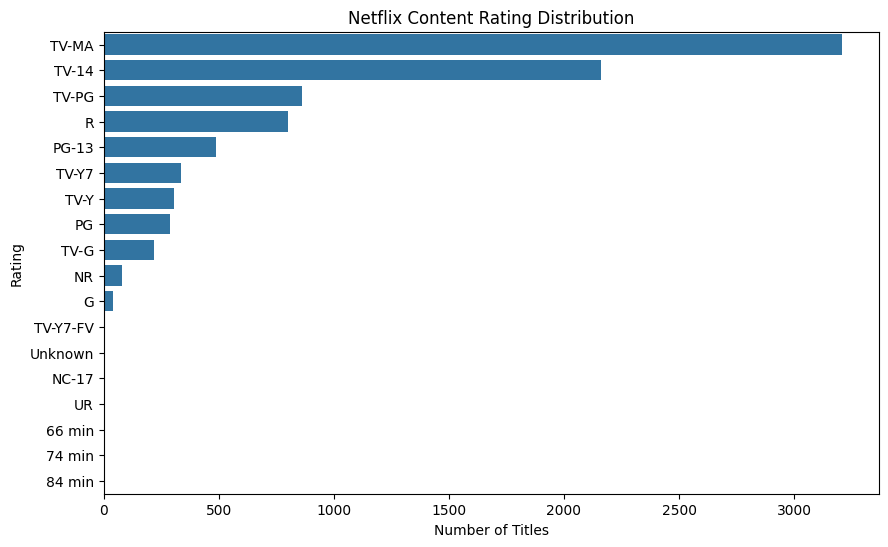

In [12]:
# Visualization 4: Rating Distribution

plt.figure(figsize=(10, 6))

sns.barplot(
    x=rating_counts.values,
    y=rating_counts.index
)

plt.title('Netflix Content Rating Distribution')
plt.xlabel('Number of Titles')
plt.ylabel('Rating')

plt.show()

In [13]:
# Count titles by release year
release_year_counts = (
    df_clean['release_year']
    .value_counts()
    .sort_index()
)

print(release_year_counts.tail(10))

release_year
2012     237
2013     288
2014     352
2015     560
2016     902
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, dtype: int64


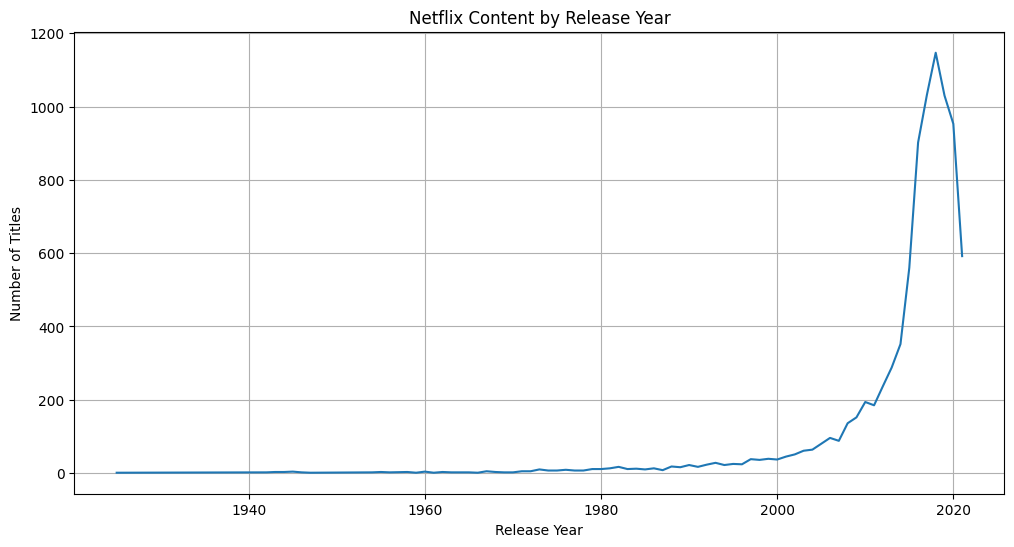

In [14]:
# Visualization 5: Content by Release Year

plt.figure(figsize=(12, 6))

plt.plot(
    release_year_counts.index,
    release_year_counts.values
)

plt.title('Netflix Content by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')

plt.grid(True)
plt.show()

In [15]:
# Split countries and count them
country_counts = (
    df_clean['country']
    .str.split(', ')
    .explode()
    .value_counts()
)

print(country_counts.head(10))

country
United States     3689
India             1046
Unknown            831
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64


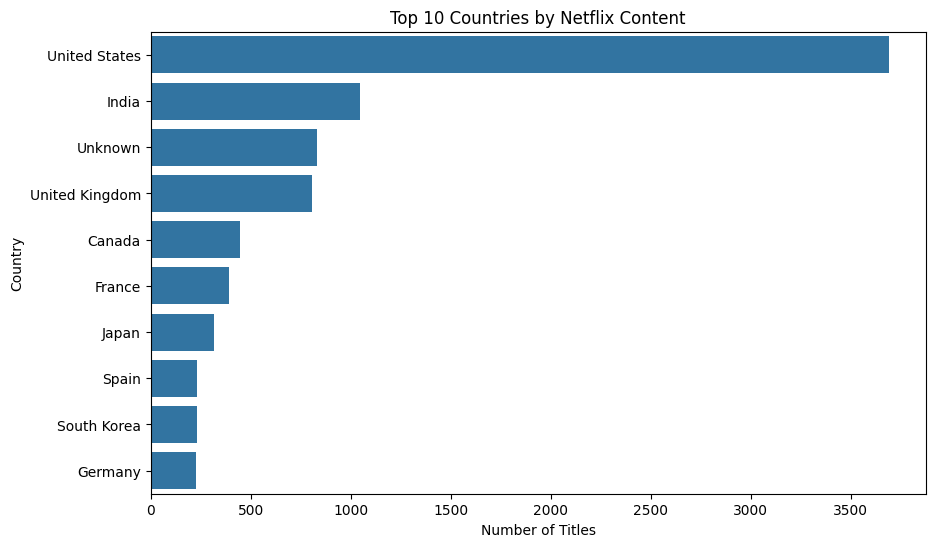

In [16]:
# Visualization 6: Top 10 Countries

top_countries = country_counts.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title('Top 10 Countries by Netflix Content')
plt.xlabel('Number of Titles')
plt.ylabel('Country')

plt.show()

In [17]:
# Key statistics for the content strategy memo

# 1. Movies vs TV Shows
content_type = df_clean['type'].value_counts()

# 2. Top 5 genres
top_5_genres = genre_counts.head(5)

# 3. Top 5 countries
top_5_countries = country_counts.head(5)

print("MOVIES VS TV SHOWS")
print(content_type)

print("\nTOP 5 GENRES")
print(top_5_genres)

print("\nTOP 5 COUNTRIES")
print(top_5_countries)

MOVIES VS TV SHOWS
type
Movie      6131
TV Show    2676
Name: count, dtype: int64

TOP 5 GENRES
listed_in
International Movies      2752
Dramas                    2427
Comedies                  1674
International TV Shows    1351
Documentaries              869
Name: count, dtype: int64

TOP 5 COUNTRIES
country
United States     3689
India             1046
Unknown            831
United Kingdom     804
Canada             445
Name: count, dtype: int64


**OTT Streaming Content Strategy Memo**

**Objective:**

Analyze Netflix's streaming catalog to identify content trends and provide actionable recommendations for content strategy.

**Key Insights:**

1. Focus on the strongest content categories
The genre analysis identifies the categories with the largest content volume. Netflix can prioritize these popular genres while also testing selected less-represented genres to reach additional audiences.

2. Maintain a balanced Movies and TV Shows portfolio
The Movies vs TV Shows analysis shows how the catalog is distributed between the two content types. Netflix can use this distribution to maintain a balanced content strategy and invest according to audience demand.

3. Strengthen regional content strategy
The country analysis highlights the countries contributing the most titles. Netflix can continue investing in strong content-producing markets while expanding regional and international content to diversify its catalog.